# Setup

In [1]:
import numpy as np
from astropy import constants as const, units as u
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
import sys
sys.path.append('../')
from functions import *

In [3]:
plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Load Data

`lisasim_snr.py` is run first to generate the data; this Notebook loads and plots that data.

In [4]:
# Load data
data = np.loadtxt('../LISAsim_data_files/snrdiff.txt')
N    = int(np.sqrt(data.shape[0]))

# Convert units
data[:,0] = data[:,0]*u.s.to(u.year)
data[:,1] = data[:,1]*u.kg.to(const.M_jup)

In [5]:
# Reshape
data = data.reshape(N,N,-1)

# IMPORTANT STEP: Must take the transpose in order to *correctly* reconstruct the data arrays as they were calculated in lisasim_snr.py!
mass   = data[:,:,0].T
period = data[:,:,1].T
snr    = data[:,:,2].T

# Plot

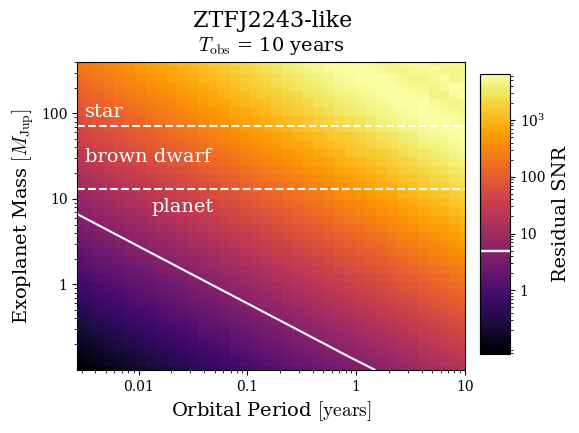

In [6]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.set_xscale('log'), ax.set_yscale('log')

pcm = ax.pcolormesh(mass, period, snr, norm=colors.LogNorm(), shading='auto', cmap='inferno')

ax.set_xlim([mass.min(), mass.max()])
ax.set_ylim([period.min(), period.max()])

# Colorbar  ----------------------------------------------------------------------------------------------------------------------------
cbar_ax = fig.add_axes([0.93, 0.15, 0.06, 0.7])
cbar    = fig.colorbar(pcm, cax=cbar_ax)
cbar.set_label('Residual SNR', fontsize=14)
cbar.ax.set_yticks([1, 10, 100, 1000]), cbar.ax.set_yticklabels(['1', '10', '100', '$\\mathdefault{10^{3}}$'])

# 5-sigma contour line -----------------------------------------------------------------------------------------------------------------
# --> this is for visual reference when looking at the plot
ax.contour(mass, period, snr, levels=[5], norm=colors.LogNorm(), colors='white', linestyles='-')

# next add just the 5-sigma line on the colorbar itself
cbar_ax2 = cbar_ax.secondary_yaxis(location=0)
cbar_ax2.set_zorder(cbar_ax.get_zorder() + 1)
cbar_ax2.set_yticks([5]), cbar_ax2.set_yticklabels([])
cbar_ax2.tick_params(color='white', direction='in', width=1.7, length=22)
cbar_ax2.yaxis.minorticks_off()

# Text and horizontal lines -------------------------------------------------------------------------------------------------------------
ax.axhline(13, linestyle='--', color='white')
ax.axhline(72, linestyle='--', color='white')
ax.text(0.19,13-6,  'planet',      fontsize=14, color='white', transform=ax.get_yaxis_transform())
ax.text(0.02,23+4,  'brown dwarf', fontsize=14, color='white', transform=ax.get_yaxis_transform())
ax.text(0.02,72+20, 'star',        fontsize=14, color='white', transform=ax.get_yaxis_transform())

# Axes labels and titles formatting  ------------------------------------------------------------------------------------------------------
ax.set_title(r'$T_\mathrm{obs}$ = 10 years', loc='center', pad=8, fontsize=14)
fig.suptitle('ZTFJ2243-like', ha='center', x=0.515, fontsize=16, y=1.01)

ax.set_xticks([1e-2,1e-1,1,1e1]), ax.set_xticklabels(['0.01', '0.1', '1', '10'])
ax.set_xlabel(r'Orbital Period $[\text{years}]$', y=-0.03, fontsize=14)

ax.set_yticks([1,1e1,1e2]), ax.set_yticklabels(['1', '10', '100'])
ax.set_ylabel(r'Exoplanet Mass $[M_\text{Jup}]$', fontsize=14)

# Rasterize the contourfs, to reduce the PDF file size significantly!
pcm.set_rasterized(True)

plt.show()
# plt.savefig('./residual_SNR.pdf', bbox_inches='tight')